<a href="https://colab.research.google.com/github/SAMIHA-BGM/Hybrid-Item-Based-Recommender/blob/main/Hybrid_Item_Based_Recommender.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans

from google.colab import files
import io

import warnings
warnings.filterwarnings('ignore')

In [9]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]), low_memory=False)

print("Loaded file:", file_name)
print("Shape:", df.shape)

df.head()

Saving amazon_products_sales_data_cleaned.csv to amazon_products_sales_data_cleaned (3).csv
Loaded file: amazon_products_sales_data_cleaned (3).csv
Shape: (42675, 17)


,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00


In [20]:
print("Dataset Shape:", df.shape)

df.info()
df.describe(include='all')

Dataset Shape: (40613, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40613 entries, 0 to 40612
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         40613 non-null  object 
 1   product_rating        40613 non-null  float64
 2   total_reviews         40613 non-null  float64
 3   purchased_last_month  40613 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        40613 non-null  int64  
 7   is_sponsored          40613 non-null  int64  
 8   has_coupon            40613 non-null  int64  
 9   buy_box_availability  40613 non-null  int64  
 10  delivery_date         30550 non-null  object 
 11  sustainability_tags   3059 non-null   object 
 12  product_image_url     40613 non-null  object 
 13  product_page_url      38609 non-null  object 
 14  data_collected_at     40613 non-null  objec

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,...,product_page_url,data_collected_at,product_category,discount_percentage,log_reviews,log_purchases,price_score,trust_score,retail_boost,final_score
count,40613,40613.000000,40613.000000,40613.000000,40613.000000,40613.000000,40613.0,40613.000000,40613.0,40613.0,...,38609,40613,40613,40613.000000,40613.000000,40613.000000,40613.000000,40613.000000,40613.0,40613.000000
unique,8386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,38609,1559,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,"Duracell Coppertop 9V Battery, 6 Count (Pack o...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,https://www.amazon.com/Lorex-8-Channel-Securit...,2025-08-21 11:15:00,Other Electronics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,744,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,33,8612,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,4.412622,2407.962087,797.786423,243.227289,257.611107,0.0,0.172309,0.0,0.0,...,NaN,NaN,NaN,6.547151,5.750931,4.055372,0.065471,25.541174,0.0,10.621063
std,NaN,0.378605,5843.680427,3109.389686,473.351545,496.633495,0.0,0.377654,0.0,0.0,...,NaN,NaN,NaN,12.744715,2.358620,2.636053,0.127447,11.023123,0.0,4.603671
min,NaN,1.000000,0.000000,0.000000,2.160000,2.160000,0.0,0.000000,0.0,0.0,...,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,NaN,4.300000,75.000000,0.000000,29.690000,32.990000,0.0,0.000000,0.0,0.0,...,NaN,NaN,NaN,0.000000,4.330733,0.000000,0.000000,18.196503,0.0,7.480208
50%,NaN,4.500000,335.000000,100.000000,84.990000,89.000000,0.0,0.000000,0.0,0.0,...,NaN,NaN,NaN,0.000000,5.817111,4.615121,0.000000,25.503389,0.0,10.582061
75%,NaN,4.700000,1754.000000,300.000000,224.000000,229.990000,0.0,0.000000,0.0,0.0,...,NaN,NaN,NaN,8.490000,7.470224,5.707110,0.084924,33.245416,0.0,13.833583


In [21]:
print("Missing Values:\n", df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Missing Values:
 product_title               0
product_rating              0
total_reviews               0
purchased_last_month        0
discounted_price            0
original_price              0
is_best_seller              0
is_sponsored                0
has_coupon                  0
buy_box_availability        0
delivery_date           10063
sustainability_tags     37554
product_image_url           0
product_page_url         2004
data_collected_at           0
product_category            0
discount_percentage         0
log_reviews                 0
log_purchases               0
price_score                 0
trust_score                 0
retail_boost                0
final_score                 0
dtype: int64
Shape after removing duplicates: (40613, 23)


In [22]:

# ==============================
# 1. Convert numeric columns safely
# ==============================
num_cols = [
    'discounted_price',
    'original_price',
    'product_rating',
    'total_reviews',
    'purchased_last_month',
    'discount_percentage'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


# ==============================
# 2. Remove invalid price rows
# ==============================
df = df[(df['original_price'] > 0) & (df['discounted_price'] > 0)]


# ==============================
# 3. Handle missing values
# ==============================
df['product_rating'].fillna(df['product_rating'].median(), inplace=True)
df['total_reviews'].fillna(0, inplace=True)
df['purchased_last_month'].fillna(0, inplace=True)
df['discount_percentage'].fillna(0, inplace=True)


# ==============================
# 4. FIX BOOLEAN COLUMNS (IMPORTANT FIX)
# ==============================
bool_cols = ['is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability']

for col in bool_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            'yes': 1,
            'true': 1,
            '1': 1,
            'available': 1,
            'sponsored': 1,
            'no': 0,
            'false': 0,
            '0': 0,
            'no badge': 0
        })
    )

    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)


# ==============================
# 5. Outlier Handling (Robust Clipping)
# ==============================
df['total_reviews'] = np.clip(
    df['total_reviews'],
    0,
    df['total_reviews'].quantile(0.99)
)

df['purchased_last_month'] = np.clip(
    df['purchased_last_month'],
    0,
    df['purchased_last_month'].quantile(0.99)
)


# ==============================
# 6. Reset Index (GOOD PRACTICE)
# ==============================
df.reset_index(drop=True, inplace=True)


# ==============================
# 7. Final Check
# ==============================
print("Final Shape:", df.shape)
df.head()

Final Shape: (40613, 23)


,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,...,product_page_url,data_collected_at,product_category,discount_percentage,log_reviews,log_purchases,price_score,trust_score,retail_boost,final_score
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,0,1,0,0,...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60,5.929589,5.707110,0.435975,27.276110,0.0,15.420611
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,0,1,0,0,...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52,7.807103,8.699681,0.375235,33.570544,0.0,17.751658
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,0,1,0,0,...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03,8.021256,7.601402,0.100287,36.897778,0.0,15.837630
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,0,0,0,0,...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00,10.488019,9.210440,0.000000,48.244887,0.0,19.188321
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,0,0,0,0,...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00,10.274672,9.210440,0.000000,49.318424,0.0,19.564059


In [23]:
# Log transformation for skewed data
df['log_reviews'] = np.log1p(df['total_reviews'])
df['log_purchases'] = np.log1p(df['purchased_last_month'])

# Price advantage
df['price_score'] = 1 - (df['discounted_price'] / df['original_price'])

# Trust score
df['trust_score'] = df['product_rating'] * df['log_reviews']

# Retail boost
df['retail_boost'] = (
    df['is_best_seller'].astype(int) * 0.3 +
    df['has_coupon'].astype(int) * 0.2 +
    df['buy_box_availability'].astype(int) * 0.5
)

# Final hybrid score
df['final_score'] = (
    df['trust_score'] * 0.35 +
    df['log_purchases'] * 0.25 +
    df['price_score'] * 0.20 +
    df['discount_percentage'] * 0.10 +
    df['retail_boost'] * 0.10
)

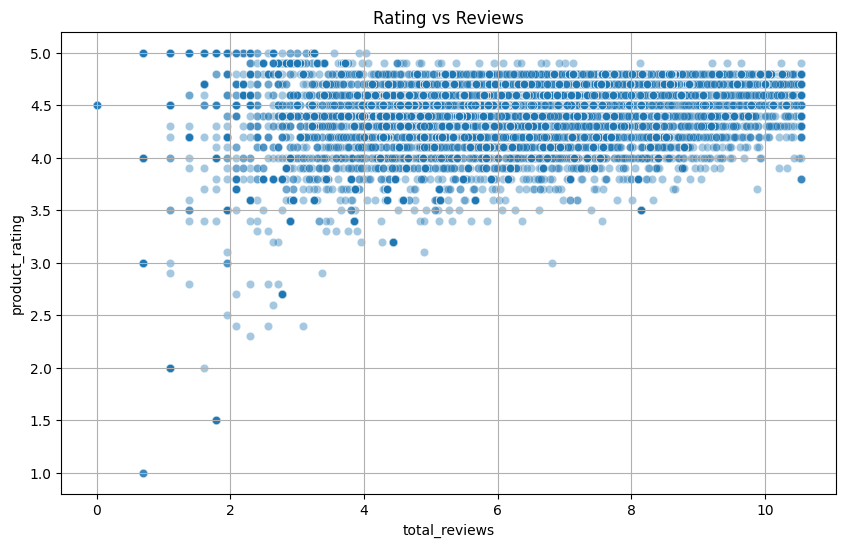

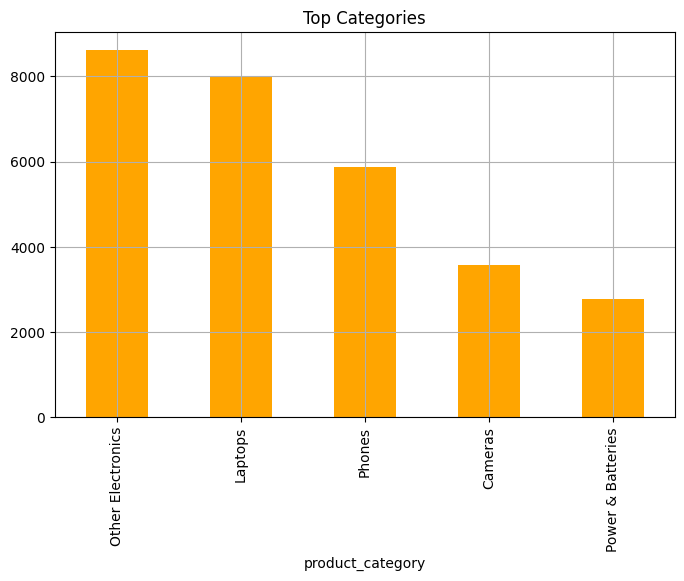

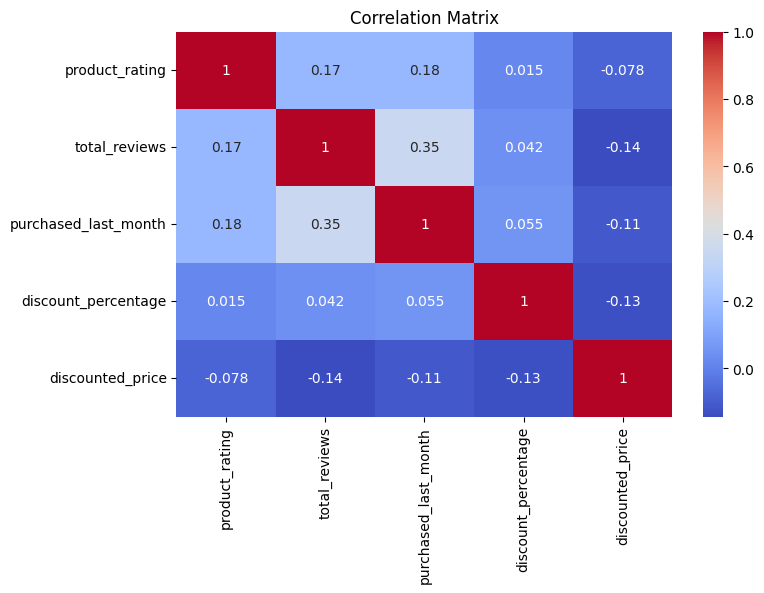

In [25]:

plt.figure(figsize=(10,6))
sns.scatterplot(x=np.log1p(df['total_reviews']), y=df['product_rating'], alpha=0.4)
plt.title("Rating vs Reviews")
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
df['product_category'].value_counts().head(5).plot(kind='bar', color='orange')
plt.title("Top Categories")
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
sns.heatmap(df[['product_rating','total_reviews','purchased_last_month',
                'discount_percentage','discounted_price']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [26]:
top_products = df.sort_values(by='final_score', ascending=False)

top_products[['product_title', 'final_score']].head(10)

,product_title,final_score
42,"Scotch Thermal Laminating Pouches, for Use wit...",24.642672
6377,Pentel GraphGear 1000 Automatic Drafting Penci...,24.553843
219,"TP-Link TL-SG105, 5 Port Gigabit Unmanaged Eth...",24.547243
140,BIC Xtra Strong Mechanical Pencils with Eraser...,24.512873
134,"Scotch Thermal Laminating Pouches, 200 Count, ...",24.366148
2423,"Energizer AA and AAA Batteries, 48 Count, Comb...",24.347033
1130,"Energizer AA and AAA Batteries, 48 Count, Comb...",24.347033
4408,"Energizer AA and AAA Batteries, 48 Count, Comb...",24.347033
820,"Energizer AA and AAA Batteries, 48 Count, Comb...",24.347033
7282,"Energizer AA and AAA Batteries, 48 Count, Comb...",24.347033


In [27]:

features = [
    'product_rating',
    'log_reviews',
    'log_purchases',
    'price_score',
    'discount_percentage',
    'retail_boost'
]

X = df[features]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
model = NearestNeighbors(
    n_neighbors=10,
    metric='cosine',
    algorithm='brute'
)

model.fit(X_scaled)

NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=10)

In [28]:
def recommend(product_index, top_n=5):

    distances, indices = model.kneighbors(
        X_scaled[product_index].reshape(1, -1),
        n_neighbors=top_n+1
    )

    rec_idx = indices.flatten()[1:]

    return df.iloc[rec_idx][[
        'product_title',
        'final_score',
        'product_rating',
        'total_reviews'
    ]]

In [29]:
recommend(10)

,product_title,final_score,product_rating,total_reviews
10,Amazon Basics 48-Pack AA Alkaline High-Perform...,19.822479,4.7,37987.6416
60,"Amazon Basics 8-Pack 9V Alkaline Batteries, 5-...",19.822479,4.7,37987.6416
15,Texas Instruments TI-30XIIS Scientific Calcula...,19.822479,4.7,37987.6416
442,Amazon Basics 6-Pack LR44 Alkaline Button Coin...,19.822479,4.7,37987.6416
191,"BIC Round Stic Xtra Life Ballpoint Pen, Ultra ...",19.822479,4.7,37987.6416


In [30]:
kmeans = KMeans(n_clusters=6, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [31]:
def recommend_cluster(product_index):

    cluster_id = df.iloc[product_index]['cluster']

    return df[df['cluster'] == cluster_id].head(5)[[
        'product_title',
        'final_score'
    ]]

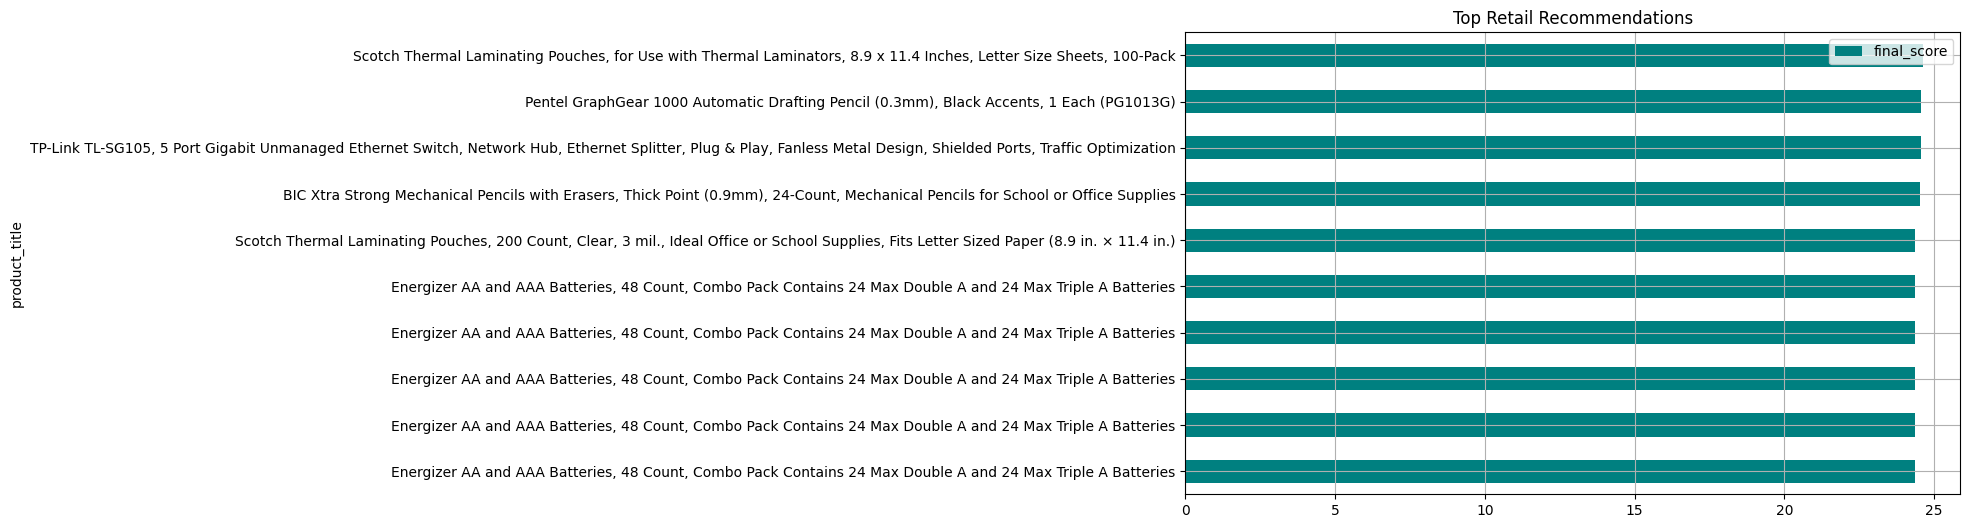

In [32]:
top_products.head(10).plot(
    x='product_title',
    y='final_score',
    kind='barh',
    figsize=(10,6),
    color='teal'
)

plt.title("Top Retail Recommendations")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()